In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
# Load the feature matrix
df = pd.read_csv("brca_metabric/feature_matrix.csv")

y = df['CLAUDIN_SUBTYPE']
X = df.drop(columns=['PATIENT_ID', 'CLAUDIN_SUBTYPE'])

#One-hot encoding is a method for converting categorical variables into a format that can be provided to machine learning algorithms to improve predictions. It creates new binary columns for each category in the original categorical column, where each column represents one category and contains 1s and 0s indicating the presence or absence of that category in the original data.
cat_cols = X.select_dtypes(include=['object', 'str']).columns.tolist() #cat_cols is a list of column names in the DataFrame X that have data types of either 'object' or 'str', which typically represent categorical variables. This list is used to identify which columns need to be one-hot encoded.
X = pd.get_dummies(X, columns=cat_cols, dummy_na=True)

print(X.shape)
display(y.value_counts().head())
#how do we know which one to be one-hot encoded? The columns that are of type 'object' or 'str' are typically categorical variables, which are suitable for one-hot encoding. In this case, we identify those columns using `select_dtypes` and then apply one-hot encoding to them.

(1974, 599)


CLAUDIN_SUBTYPE
LumA           700
LumB           475
Her2           224
claudin-low    218
Basal          209
Name: count, dtype: int64

In [3]:
intclust_cols = [c for c in X.columns if c.startswith('INTCLUST_')]
X_clean = X.drop(columns=intclust_cols)
print(f"Dropped {len(intclust_cols)} INTCLUST columns")

Dropped 12 INTCLUST columns


In [4]:
#Split and scale the data
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, stratify=y, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Export the actual held-out test-set patients (raw, pre-encoding) for honest accuracy checks in the app
test_patients = df.loc[X_test.index]
test_patients.to_csv("brca_metabric/test_patients.csv", index=False)
print(f"Saved {len(test_patients)} test-set patients to test_patients.csv")

Saved 395 test-set patients to test_patients.csv


In [6]:
import sys
!{sys.executable} -m pip install xgboost

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_train)  # e.g. Basal=0, Her2=1, LumA=2, LumB=3, Normal=4, claudin-low=5

print(dict(zip(le.classes_, le.transform(le.classes_))))  # see the mapping

{'Basal': np.int64(0), 'Her2': np.int64(1), 'LumA': np.int64(2), 'LumB': np.int64(3), 'Normal': np.int64(4), 'claudin-low': np.int64(5)}


In [9]:
#Train models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

models = {
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='mlogloss', random_state=42)
}

for name, model in models.items():
    if name == 'XGBoost':
        scores = cross_val_score(model, X_train_scaled, y_encoded, cv=5, scoring='f1_macro') #cv is the number of folds in cross-validation, and scoring='f1_macro' means we are using the macro-averaged F1 score as the evaluation metric.
    else:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1_macro')
    print(f"{name}: macro-F1 = {scores.mean():.3f} (+/- {scores.std():.3f})")


RandomForest: macro-F1 = 0.747 (+/- 0.015)


d:\Anaconda\envs\biostruct\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Anaconda\envs\biostruct\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Anaconda\envs\biostruct\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Anaconda\envs\biostruct\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.

SVM: macro-F1 = 0.769 (+/- 0.033)
XGBoost: macro-F1 = 0.783 (+/- 0.019)


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt

#Encode target — XGBoost requires integers, not strings
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

best_model = XGBClassifier(eval_metric='mlogloss', random_state=42)
best_model.fit(X_train_scaled, y_train_encoded)
y_pred_encoded = best_model.predict(X_test_scaled)

#Decode predictions back to subtype names for readable output
y_pred = le.inverse_transform(y_pred_encoded)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Basal       0.85      0.81      0.83        42
        Her2       0.78      0.71      0.74        45
        LumA       0.85      0.94      0.89       140
        LumB       0.82      0.84      0.83        95
      Normal       0.79      0.52      0.62        29
 claudin-low       0.82      0.82      0.82        44

    accuracy                           0.83       395
   macro avg       0.82      0.77      0.79       395
weighted avg       0.83      0.83      0.83       395



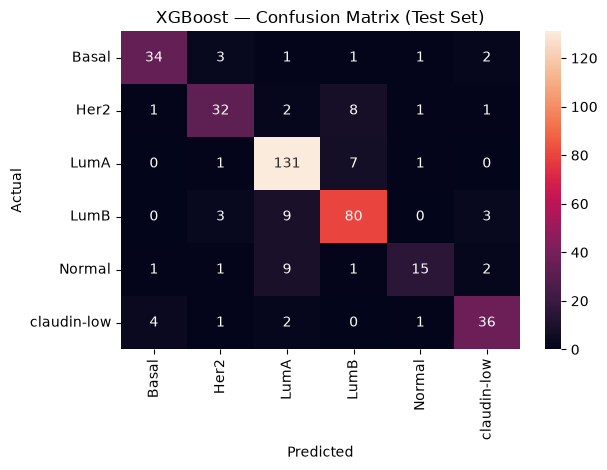

In [11]:
#Confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows the visualization of the performance of an algorithm. The confusion matrix shows the number of correct and incorrect predictions made by the model compared to the actual classifications in the test data. Each row of the matrix represents the instances in an actual class, while each column represents the instances in a predicted class.
cm = confusion_matrix(y_test, y_pred, labels=le.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('XGBoost — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

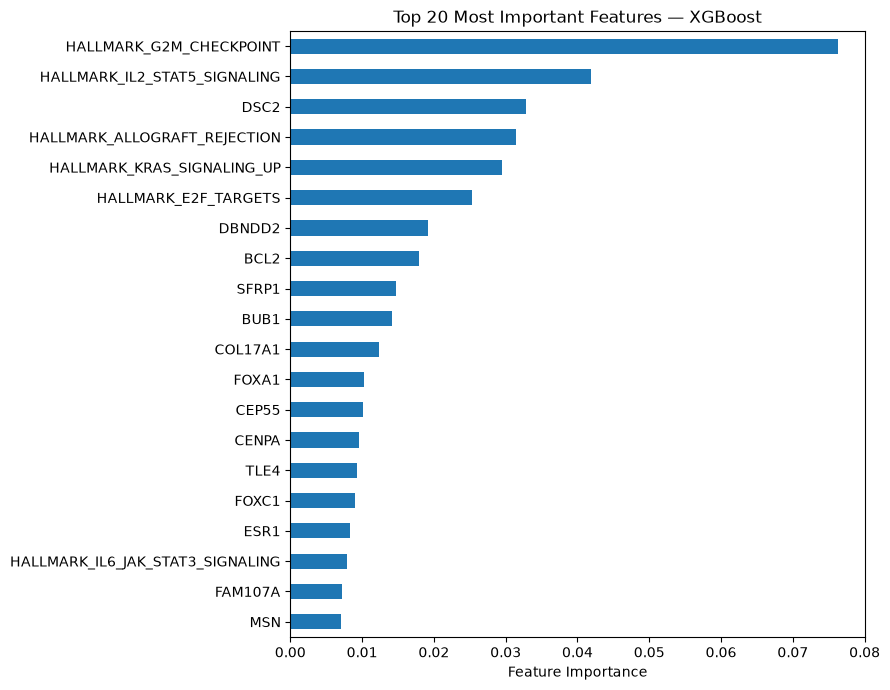

HALLMARK_G2M_CHECKPOINT             0.076272
HALLMARK_IL2_STAT5_SIGNALING        0.041944
DSC2                                0.032793
HALLMARK_ALLOGRAFT_REJECTION        0.031401
HALLMARK_KRAS_SIGNALING_UP          0.029426
HALLMARK_E2F_TARGETS                0.025326
DBNDD2                              0.019121
BCL2                                0.017907
SFRP1                               0.014748
BUB1                                0.014155
COL17A1                             0.012318
FOXA1                               0.010280
CEP55                               0.010091
CENPA                               0.009590
TLE4                                0.009333
FOXC1                               0.009073
ESR1                                0.008256
HALLMARK_IL6_JAK_STAT3_SIGNALING    0.007891
FAM107A                             0.007204
MSN                                 0.007125
dtype: float32


In [12]:
#Importance of features in the model can be assessed using the feature_importances_ attribute of the trained model. This attribute provides a score for each feature, indicating its relative importance in making predictions. Higher scores indicate more important features. Visualizing these importances can help identify which features contribute most to the model's decisions.
#Feature importance
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    best_model.feature_importances_,
    index=X_clean.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
importances.head(20).plot(kind='barh')
plt.gca().invert_yaxis()  # highest importance at top
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Features — XGBoost')
plt.tight_layout()
plt.show()

print(importances.head(20))

In [13]:
#Saving the model artifacts (model, scaler, feature names, label encoder) for future use
import joblib

joblib.dump(best_model, 'models/clinstrat_model.pkl')
joblib.dump(scaler, 'models/clinstrat_scaler.pkl')
joblib.dump(list(X_clean.columns), 'models/clinstrat_features.pkl')
joblib.dump(le, 'models/clinstrat_label_encoder.pkl')

print("Model artifacts saved.")

Model artifacts saved.


In [14]:
import pandas as pd
import joblib

model = joblib.load('models/clinstrat_model.pkl')
scaler = joblib.load('models/clinstrat_scaler.pkl')
feature_columns = joblib.load('models/clinstrat_features.pkl')
label_encoder = joblib.load('models/clinstrat_label_encoder.pkl')

def predict_subtype(new_patient_dict):
    new_df = pd.DataFrame([new_patient_dict])
    cat_cols = new_df.select_dtypes(include=['object', 'str']).columns.tolist()
    new_df = pd.get_dummies(new_df, columns=cat_cols, dummy_na=True)
    new_df = new_df.reindex(columns=feature_columns, fill_value=0)
    new_scaled = scaler.transform(new_df)
    pred_encoded = model.predict(new_scaled)
    pred_proba = model.predict_proba(new_scaled)
    pred_label = label_encoder.inverse_transform(pred_encoded)[0]
    proba_dict = dict(zip(label_encoder.classes_, pred_proba[0]))
    return pred_label, proba_dict

In [15]:
example_patient = {
    'AGE_AT_DIAGNOSIS': 62,
    'NPI': 5.2,
    'LYMPH_NODES_EXAMINED_POSITIVE': 3,
    'CELLULARITY': 'High',
    'CHEMOTHERAPY': 'YES',
    'ER_IHC': 'Positve',
    'HORMONE_THERAPY': 'YES',
    # ... gene + pathway values go here too
}

label, probs = predict_subtype(example_patient)
print(f"Predicted subtype: {label}")
print(f"Class probabilities: {probs}")

Predicted subtype: LumA
Class probabilities: {'Basal': np.float32(0.011273857), 'Her2': np.float32(0.075527094), 'LumA': np.float32(0.6298661), 'LumB': np.float32(0.11563967), 'Normal': np.float32(0.124592155), 'claudin-low': np.float32(0.043101113)}


In [16]:
#Sanity check
sample_index = 0
sample_row_scaled = X_test_scaled[sample_index].reshape(1, -1)

pred_encoded = model.predict(sample_row_scaled)
pred_proba = model.predict_proba(sample_row_scaled)
pred_label = label_encoder.inverse_transform(pred_encoded)[0]

true_label = y_test.iloc[sample_index]

print(f"Predicted: {pred_label}")
print(f"Actual:    {true_label}")
print(f"Class probabilities: {dict(zip(label_encoder.classes_, pred_proba[0]))}")

Predicted: LumB
Actual:    LumB
Class probabilities: {'Basal': np.float32(8.859895e-05), 'Her2': np.float32(0.0002516515), 'LumA': np.float32(0.022227941), 'LumB': np.float32(0.9773287), 'Normal': np.float32(7.013421e-05), 'claudin-low': np.float32(3.2885226e-05)}


In [17]:
best_model.score(X_test_scaled, y_test_encoded)

0.830379746835443

In [18]:
from sklearn.metrics import cohen_kappa_score

pred_encoded_full = model.predict(X_test_scaled)  # full 395-row prediction, fresh variable name
kappa = cohen_kappa_score(y_test_encoded, pred_encoded_full)
print(f"Cohen's Kappa: {kappa:.3f}")

Cohen's Kappa: 0.778
